Лабораторна робота №3
Тема: Візуалізація даних
Виконав: Сиротін Максим фб-42

Завдання 1 та 2: Обрати унікальний датасет з UCI Machine Learning Repository (Multivariate, Categorical/Integer/Real, >2 числових атрибутів, має пропущені значення). Здійснити Data Cleaning.

In [1]:
import pandas as pd
import numpy as np

print("Завантаження датасету Automobile з репозиторію UCI...")
headers = ["symboling", "normalized-losses", "make", "fuel-type", "aspiration", 
           "num-of-doors", "body-style", "drive-wheels", "engine-location", 
           "wheel-base", "length", "width", "height", "curb-weight", "engine-type", 
           "num-of-cylinders", "engine-size", "fuel-system", "bore", "stroke", 
           "compression-ratio", "horsepower", "peak-rpm", "city-mpg", "highway-mpg", "price"]

file_path = "imports-85.data"
df = pd.read_csv(file_path, names=headers, na_values="?")

print(f"Початковий розмір датасету: {df.shape}")
print("\nПропуски по колонках до очищення:")
print(df.isnull().sum()[df.isnull().sum() > 0])

df = df.dropna(subset=['price'])

numeric_cols_with_na = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm']
for col in numeric_cols_with_na:
    df[col] = df[col].fillna(df[col].mean())

df['num-of-doors'] = df['num-of-doors'].fillna(df['num-of-doors'].mode()[0])

print(f"\nРозмір датасету після Data Cleaning: {df.shape}")
print("Залишок пропусків:", df.isnull().sum().sum(), "(має бути 0)")

display(df.head())

Завантаження датасету Automobile з репозиторію UCI...
Початковий розмір датасету: (205, 26)

Пропуски по колонках до очищення:
normalized-losses    41
num-of-doors          2
bore                  4
stroke                4
horsepower            2
peak-rpm              2
price                 4
dtype: int64

Розмір датасету після Data Cleaning: (201, 26)
Залишок пропусків: 0 (має бути 0)


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,122.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


Завдання 3 та 4: Базові візуалізації
Завдання 3:Графік залежності ціни автомобіля (`price`) від об'єму двигуна (`engine-size`). Використовуємо діаграму розсіювання (Scatter plot).
Завдання 4: Гістограма розподілу цін на автомобілі, розбита рівно на 5 діапазонів.


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


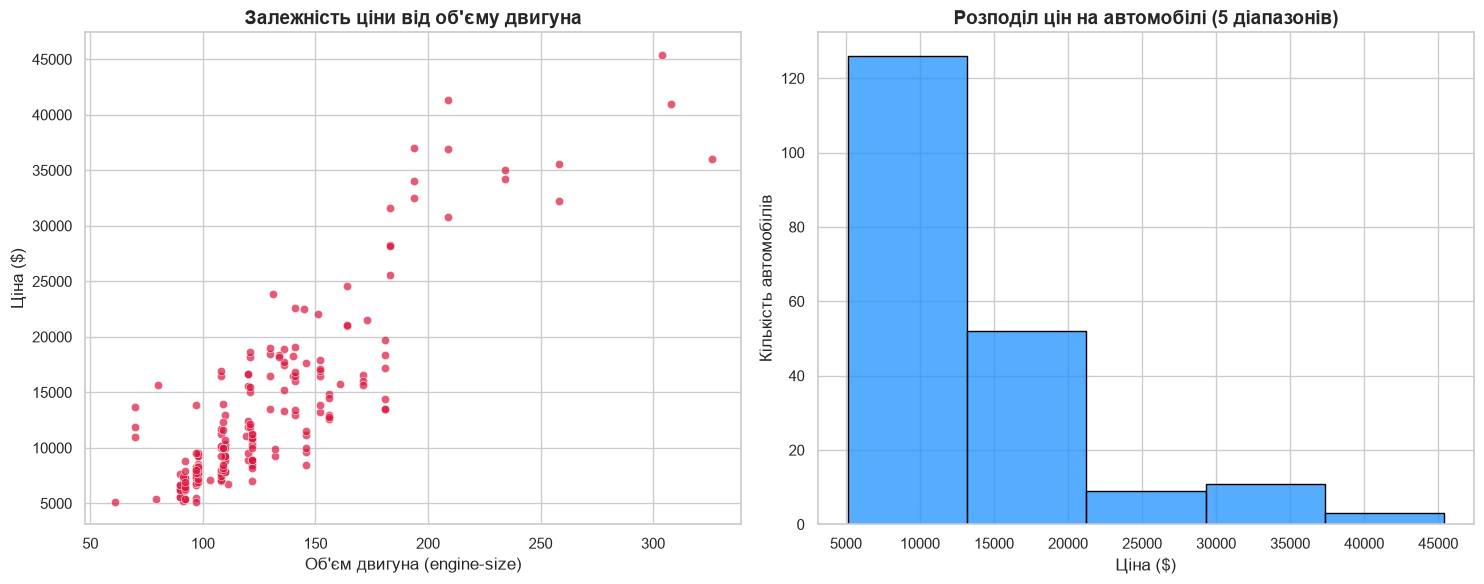

In [2]:
%pip install matplotlib seaborn -q

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(data=df, x='engine-size', y='price', ax=axes[0], color='crimson', alpha=0.7)
axes[0].set_title('Залежність ціни від об\'єму двигуна', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Об\'єм двигуна (engine-size)', fontsize=12)
axes[0].set_ylabel('Ціна ($)', fontsize=12)

sns.histplot(data=df, x='price', bins=5, ax=axes[1], color='dodgerblue', edgecolor='black')
axes[1].set_title('Розподіл цін на автомобілі (5 діапазонів)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Ціна ($)', fontsize=12)
axes[1].set_ylabel('Кількість автомобілів', fontsize=12)

plt.tight_layout()
plt.show()

Завдання 5 та 6: Розширена візуалізація
Завдання 5: Візуалізація залежностей між кількома змінними (тип приводу, стиль кузова та ціна) за допомогою `boxplot` та `barplot`. Це дозволяє оцінити багатовимірні дані.
Завдання 6: Кореляційна матриця (heatmap), що показує зв'язок між усіма числовими параметрами автомобілів.

C:\Users\Алина\AppData\Local\Temp\ipykernel_17044\427588378.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='drive-wheels', y='price', ax=axes[0, 0], palette='viridis')
C:\Users\Алина\AppData\Local\Temp\ipykernel_17044\427588378.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='body-style', y='price', ax=axes[0, 1], palette='magma')


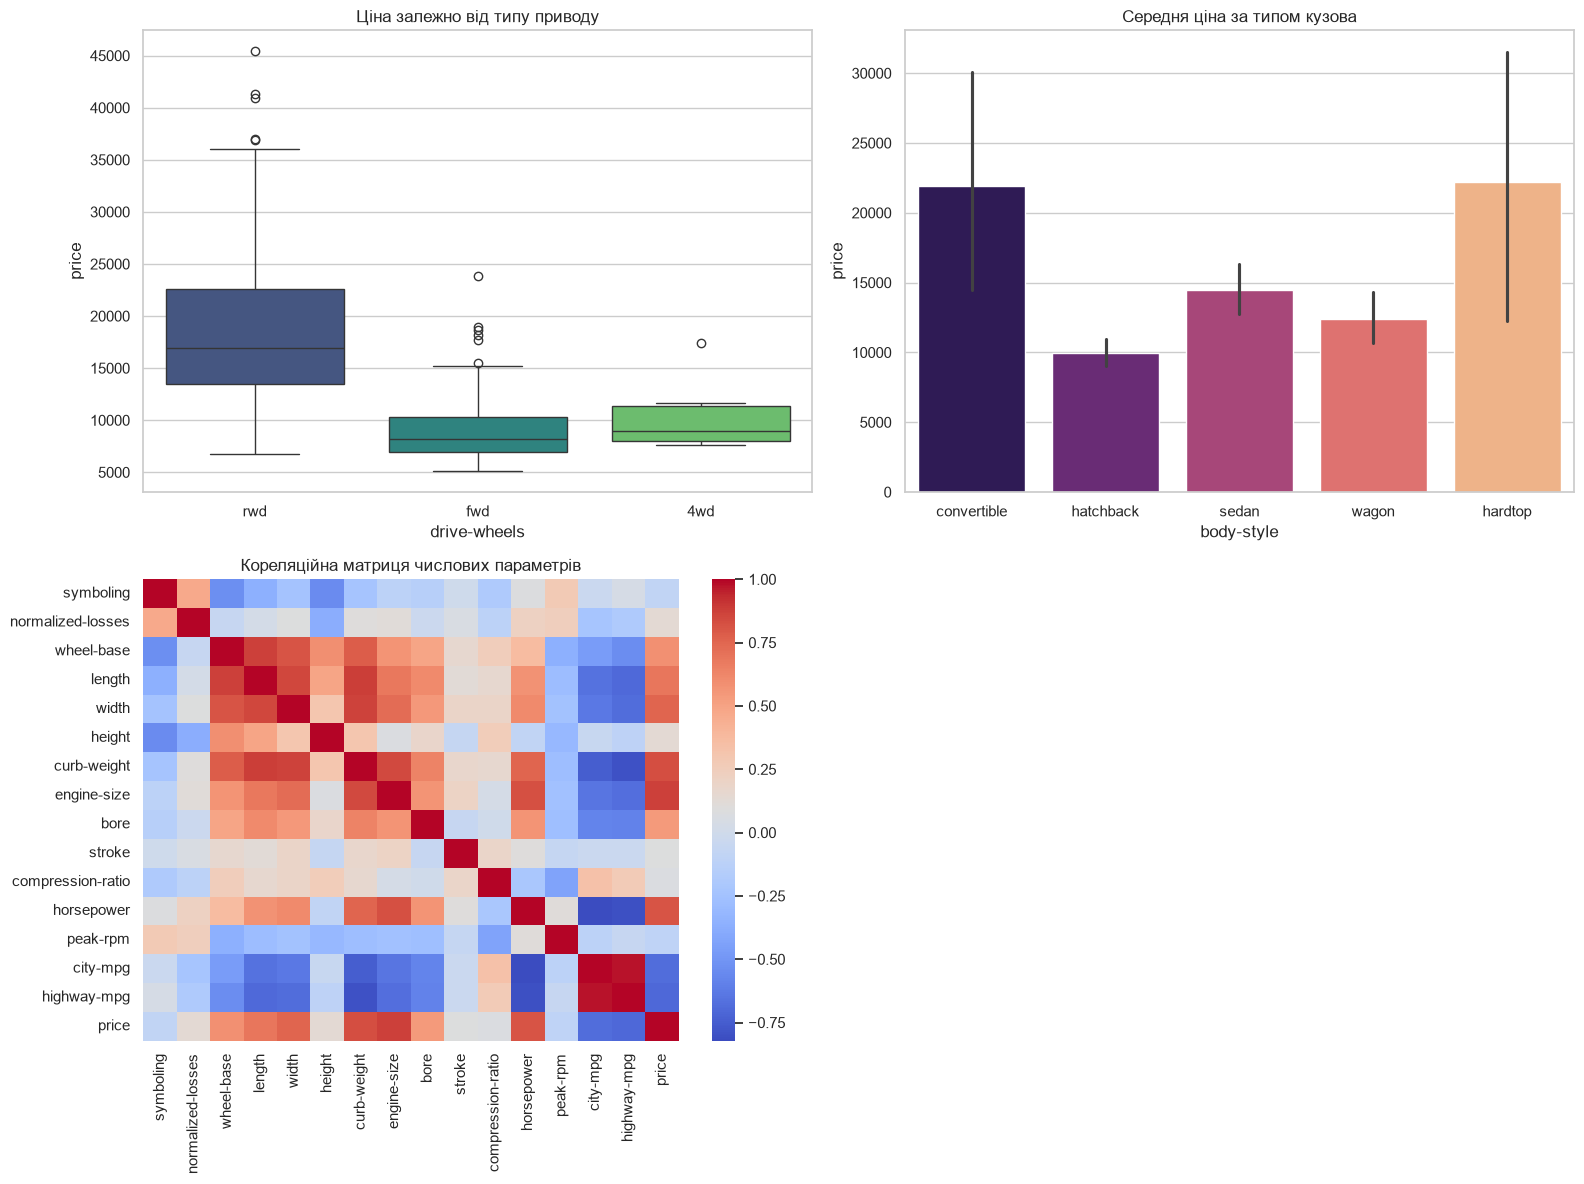

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.boxplot(data=df, x='drive-wheels', y='price', ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Ціна залежно від типу приводу', fontsize=12)

sns.barplot(data=df, x='body-style', y='price', ax=axes[0, 1], palette='magma')
axes[0, 1].set_title('Середня ціна за типом кузова', fontsize=12)

numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm', ax=axes[1, 0])
axes[1, 0].set_title('Кореляційна матриця числових параметрів', fontsize=12)

fig.delaxes(axes[1, 1])

plt.tight_layout()
plt.show()